In [384]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Understanding

In [385]:
import pandas as pd

In [386]:
df = pd.read_csv("/content/drive/MyDrive/Internship projects/Major/signal_data.csv")

In [387]:
df.shape

(1567, 592)

In [388]:
df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [389]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB


In [390]:
print("1 = Pass -1 = Fail")
df['Pass/Fail'].value_counts()

1 = Pass -1 = Fail


,count
Pass/Fail,
-1,1463
1,104


## Data Cleaning

In [391]:
df.drop('Time', axis=1, inplace=True)

In [392]:
missing = df.isnull().sum()
missing[missing > 0]

,0
0,6
1,7
2,14
3,14
4,14
...,...
585,1
586,1
587,1
588,1


In [393]:
threshold = len(df) * 0.5

df = df.loc[:, df.isnull().sum() < threshold]

In [394]:
df.loc[:, df.isnull().sum() < threshold]

,0,1,2,3,4,5,6,7,8,9,...,577,582,583,584,585,586,587,588,589,Pass/Fail
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,14.9509,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,-0.0045,...,11.7256,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,-1
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,-0.0061,...,17.8379,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,-1
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,NaN,...,17.7267,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,-1
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,-0.0072,...,19.2104,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,-1


In [395]:
for col in df.columns:
  if df[col].isnull().sum() > 0:
    df[col] = df[col].fillna(df[col].median())

In [396]:
df.drop_duplicates(inplace=True)

## Feature Reduction

In [397]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=50
)

X_selected = selector.fit_transform(X,y);

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  5  13  42  49  52  69  94 135 143 170 171 178 181 182 183 184 185 186
 217 220 221 222 223 224 225 226 227 228 231 232 233 234 244 245 246 247
 248 249 250 251 252 253 254 264 272 299 300 301 308 311 312 313 314 315
 316 347 352 353 354 355 356 357 358 361 362 363 364 374 375 376 377 378
 379 380 381 382 383 384 394 402 429 430 431 438 441 442 443 444 445 446
 461 477 480 481 482 483 484 485 486 487 488 491 492 493 494 504 505 506
 507 508 509 510 511 512 513 514] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


## Exploratory Data Analysis

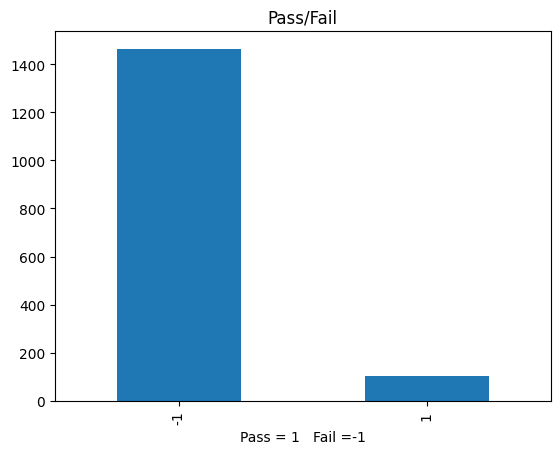

In [398]:
import matplotlib.pyplot as plt
df["Pass/Fail"].value_counts().plot(kind="bar")
plt.title("Pass/Fail")
plt.xlabel("Pass = 1   Fail =-1")
plt.show()

## Data Preparation

In [399]:
df["Pass/Fail"] = df["Pass/Fail"].replace(
    {
        1 :1,
        -1:0
    }
)

In [400]:
from sklearn.model_selection import train_test_split
X = df.drop("Pass/Fail", axis =1)
y= df["Pass/Fail"]

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify = y)

## Handle Imbalance

In [401]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

## Build LogisticRegression Model

In [402]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

model.fit(X_train_smote,y_train_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=500)

In [403]:
y_pred = model.predict(X_test)

## Evaluation

In [404]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.96      0.82      0.89       293
           1       0.19      0.57      0.28        21

    accuracy                           0.81       314
   macro avg       0.58      0.70      0.59       314
weighted avg       0.91      0.81      0.85       314



## Build RandomForestClassifier Model and Evaluation

In [405]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=300,
                       random_state=42)

In [406]:
y_pred = rf.predict(X_test)

In [407]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       293
           1       0.27      0.19      0.22        21

    accuracy                           0.91       314
   macro avg       0.60      0.58      0.59       314
weighted avg       0.90      0.91      0.90       314



In [408]:
y_pred = rf.predict(X_test)

pd.Series(y_pred).value_counts()

,count
0,299
1,15


In [409]:
y_prob = rf.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.20).astype(int)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.67      0.79       293
           1       0.15      0.81      0.25        21

    accuracy                           0.68       314
   macro avg       0.56      0.74      0.52       314
weighted avg       0.92      0.68      0.76       314



In [410]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", roc_auc)

ROC AUC: 0.7983910287664554


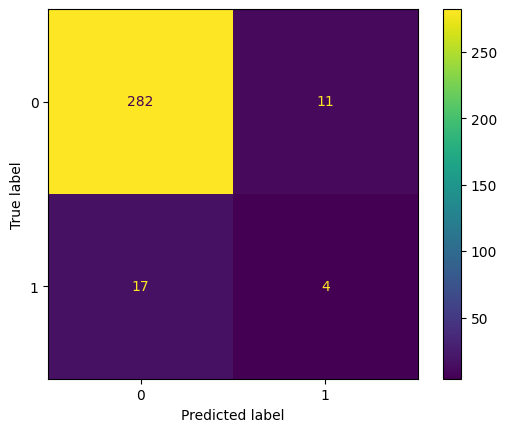

In [411]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.show()

In [412]:
selected_features = X.columns[selector.get_support()]

print(len(selected_features))

50


In [413]:
importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
49,519,0.065849
31,247,0.061660
5,33,0.054438
10,95,0.052329
12,103,0.048115
7,59,0.039107
21,130,0.033713
11,100,0.030737
1,21,0.024948
48,510,0.022644


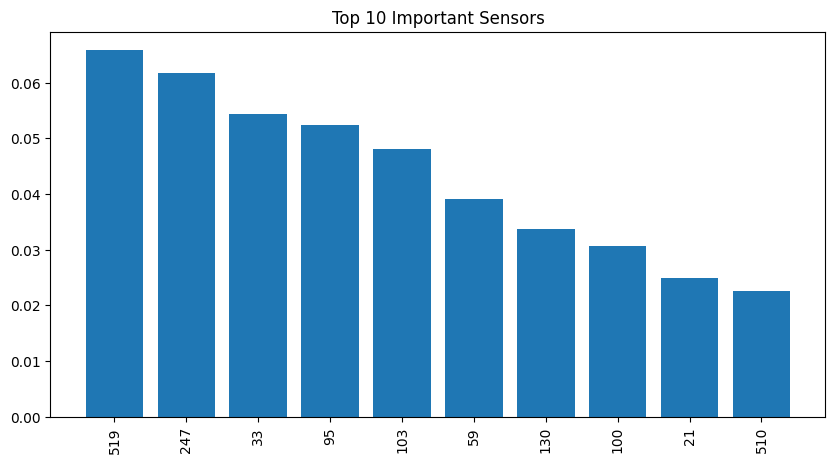

In [414]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,5))

plt.bar(top10['Feature'].astype(str),
        top10['Importance'])

plt.xticks(rotation=90)

plt.title("Top 10 Important Sensors")

plt.show()